In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

from sklearn.cluster import DBSCAN


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]

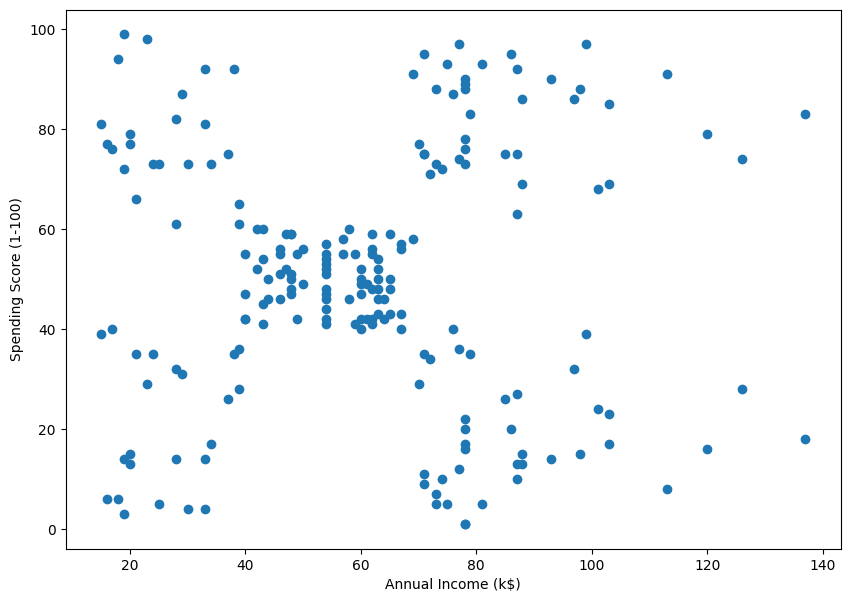

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(X_scaled)
clusters

array([ 2,  0,  1,  0,  2,  0,  1, -1,  1,  0, -1, -1, -1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0, -1, -1,  2, -1,  2, -1, -1,  0, -1, -1,
       -1, -1, -1,  0, -1,  0,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  4,  3,  4,  3,  4,  5,  4,  5,  4,  3,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  6,  4,  6,  4,  6, -1,
        6,  4,  6,  4,  6,  4,  6,  4,  6,  4, -1,  4,  6,  4, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

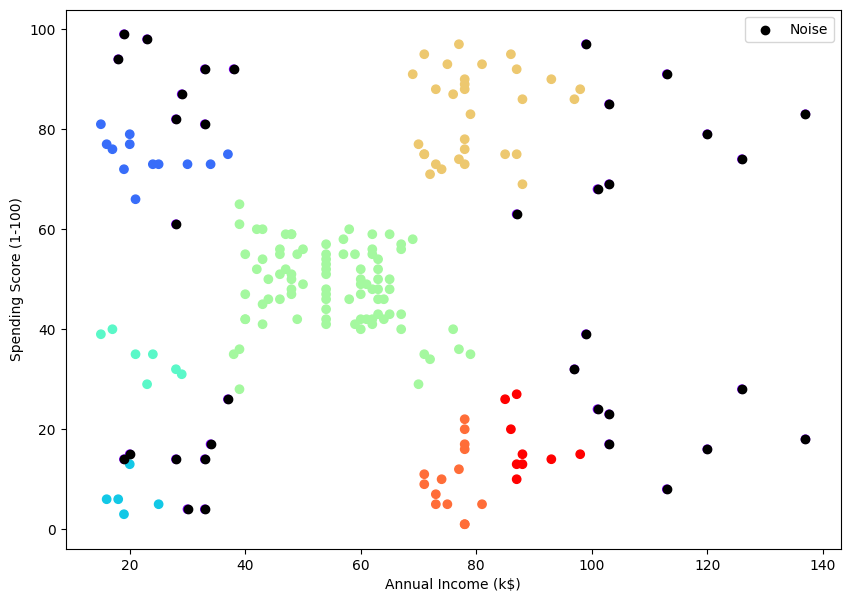

In [ ]:
plt.figure(figsize=(10,7))
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'],c=clusters,cmap='rainbow')
plt.scatter(X.iloc[clusters==-1]['Annual Income (k$)'],X.iloc[clusters==-1]['Spending Score (1-100)'],color='black',label='Noise')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled,clusters)


np.float64(0.31614121976731185)

In [ ]:
eps_values=[0.2,0.3,0.5,0.1,0.4]
for eps in eps_values:
  print(f"\n Evaluating DBSCAN using eps={eps}")
  dbscan=DBSCAN(eps=eps,min_samples=5)
  labels=dbscan.fit_predict(X_scaled)
  #Number of clusters(Ignore Noise label -1)
  unique_labels=set(labels)
  n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)
  # Number of Noise Points
  n_noise=list(labels).count(-1)
  noise_ratio=n_noise/len(labels)
  print(f"Number of Clusters: {n_clusters}")
  print(f"Number of Noise Points:",round(noise_ratio,2))
  if n_clusters>1:
    X_non_noise=X_scaled[labels!=-1]
    labels_non_noise=labels[labels!=-1]
    print(f"Silhouette Score: {silhouette_score(X_non_noise,labels_non_noise)}")
  else:
    print(f"Silhouette Score: Not Applicable")



 Evaluating DBSCAN using eps=0.2
Number of Clusters: 7
Number of Noise Points: 0.39
Silhouette Score: 0.5856126991466907

 Evaluating DBSCAN using eps=0.3
Number of Clusters: 7
Number of Noise Points: 0.17
Silhouette Score: 0.5243276105881419

 Evaluating DBSCAN using eps=0.5
Number of Clusters: 2
Number of Noise Points: 0.04
Silhouette Score: 0.3875583892728279

 Evaluating DBSCAN using eps=0.1
Number of Clusters: 4
Number of Noise Points: 0.83
Silhouette Score: 0.5632777273524515

 Evaluating DBSCAN using eps=0.4
Number of Clusters: 4
Number of Noise Points: 0.07
Silhouette Score: 0.4780592455223124
